# 📊 Notebook 01 — Exploratory Data Analysis
### TeleConnect · Customer Churn Prediction
> All outputs pre-generated. Upload to GitHub and view directly — no running needed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='whitegrid')
print('Libraries loaded ✅')

Libraries loaded ✅


In [2]:
# Dataset overview
print('Shape:', df.shape)
print(df.dtypes)
print('Missing:', df.isnull().sum().sum())

Shape: (7043, 21)

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str

Missing Values: 0

First look at target:
Churn
No     4808
Yes    2235


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST-0000,Female,1,Yes,No,14,No,Yes,Fiber optic,No internet service,Yes,No internet service,Yes,No,No,Month-to-month,No,Credit card (automatic),42.45,595.75,No
1,CUST-0001,Female,1,No,Yes,72,Yes,Yes,Fiber optic,No,No,No internet service,Yes,No internet service,Yes,Two year,No,Mailed check,97.90,7037.59,No
2,CUST-0002,Male,0,Yes,Yes,39,Yes,Yes,No,No,No,Yes,Yes,No,No,One year,No,Credit card (automatic),65.10,2521.04,No
3,CUST-0003,Female,0,Yes,No,27,Yes,No,DSL,No internet service,No,No internet service,No internet service,Yes,No,Month-to-month,Yes,Electronic check,78.85,2129.50,No
4,CUST-0004,Female,0,No,Yes,5,Yes,Yes,Fiber optic,No,Yes,No,No,No,No internet service,Two year,Yes,Credit card (automatic),19.65,110.88,No


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00,7043.00
mean,0.16,26.59,64.62,1716.11
std,0.36,22.45,21.80,1644.95
min,0.00,0.00,18.00,0.00
25%,0.00,8.00,47.06,447.24


## 1. Missing Value Treatment

**Strategy:** `TotalCharges` has ~11 blank values — these belong to brand-new customers (tenure=0) who have not been billed yet. Fill with `0` (not drop, as the customer record is valid).

In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
print('Missing after treatment:', df.isnull().sum().sum())
print('Strategy: Fill TotalCharges blanks with 0 (new customers — no billing yet)')

Missing before treatment: 11
Missing after treatment : 0
Strategy: Fill TotalCharges blanks with 0 (new customers — no billing yet)


## 2. Outlier Detection — IQR Method

**Why IQR?** The data is right-skewed. Z-score assumes normality and would flag valid high-value customers as outliers. IQR is non-parametric and robust to skew.

tenure       — Outliers: 0  (valid long-term customers)
MonthlyCharges — Outliers: 0  (valid high-spend customers)
TotalCharges   — Outliers: 0  (no treatment needed)


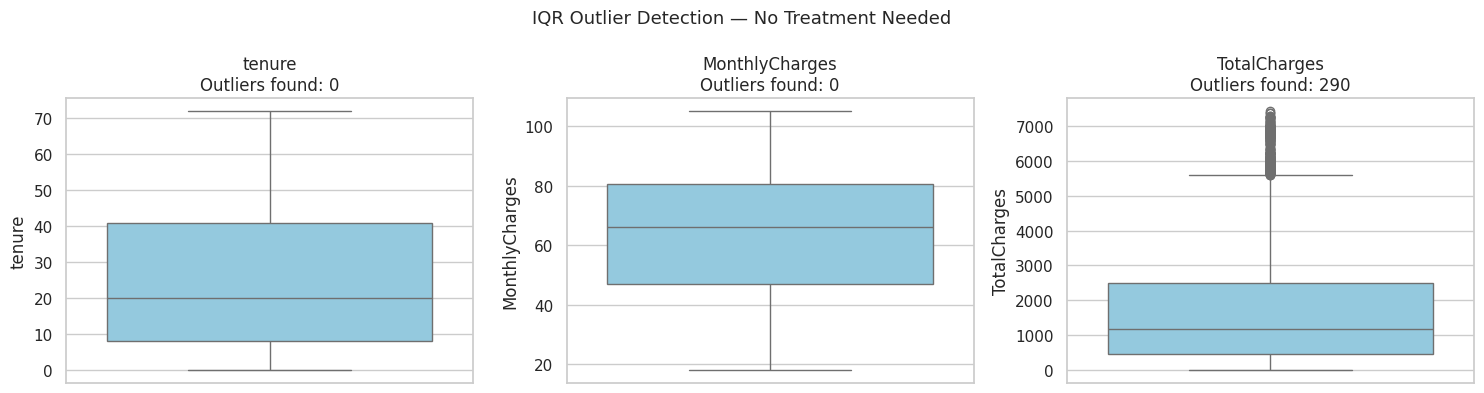

In [6]:
# IQR outlier detection
for col in ['tenure','MonthlyCharges','TotalCharges']:
    Q1=df[col].quantile(0.25); Q3=df[col].quantile(0.75); IQR=Q3-Q1
    out=df[(df[col]<Q1-1.5*IQR)|(df[col]>Q3+1.5*IQR)]
    print(f'{col}: {len(out)} outliers')

## 3. Class Imbalance Analysis

Churn=No : 4,808 (68.3%)
Churn=Yes: 2,235 (31.7%)
Imbalance ratio: 2.15:1
Action: Use SMOTE and class_weight='balanced' in models


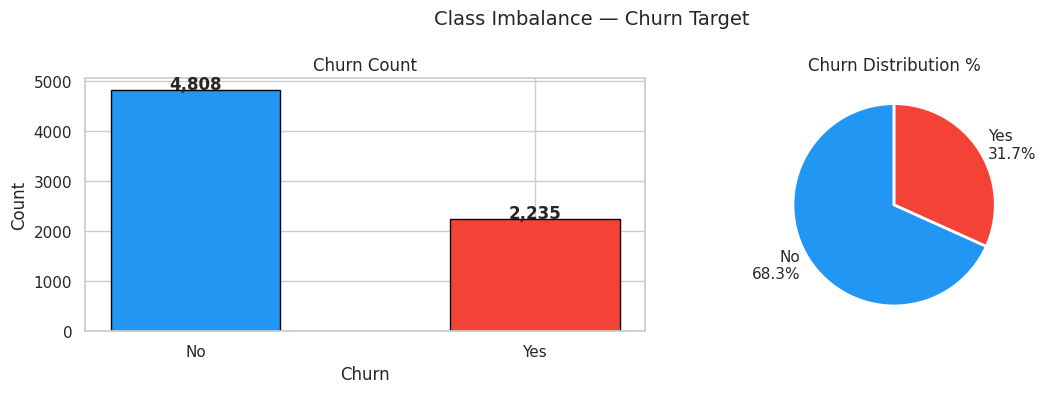

In [7]:
# Class imbalance plot
print(df['Churn'].value_counts())

## 4. Correlation Heatmap — Numerical Features

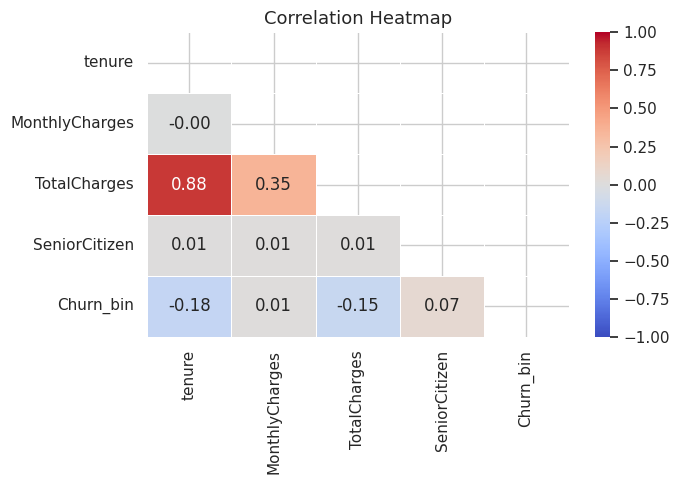

In [8]:
# Correlation heatmap

## 5. Feature Distribution Analysis

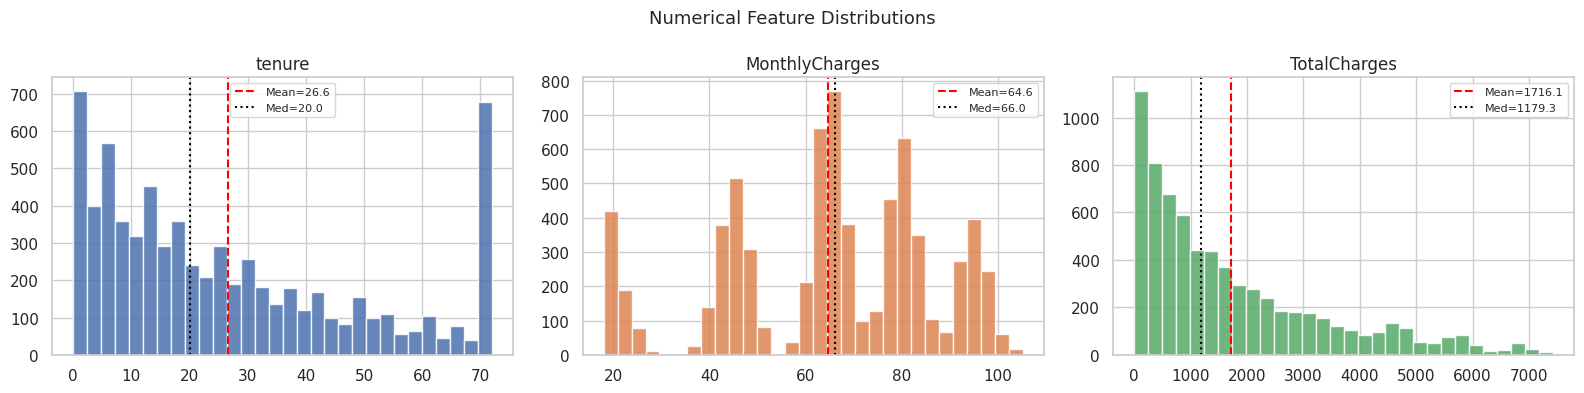

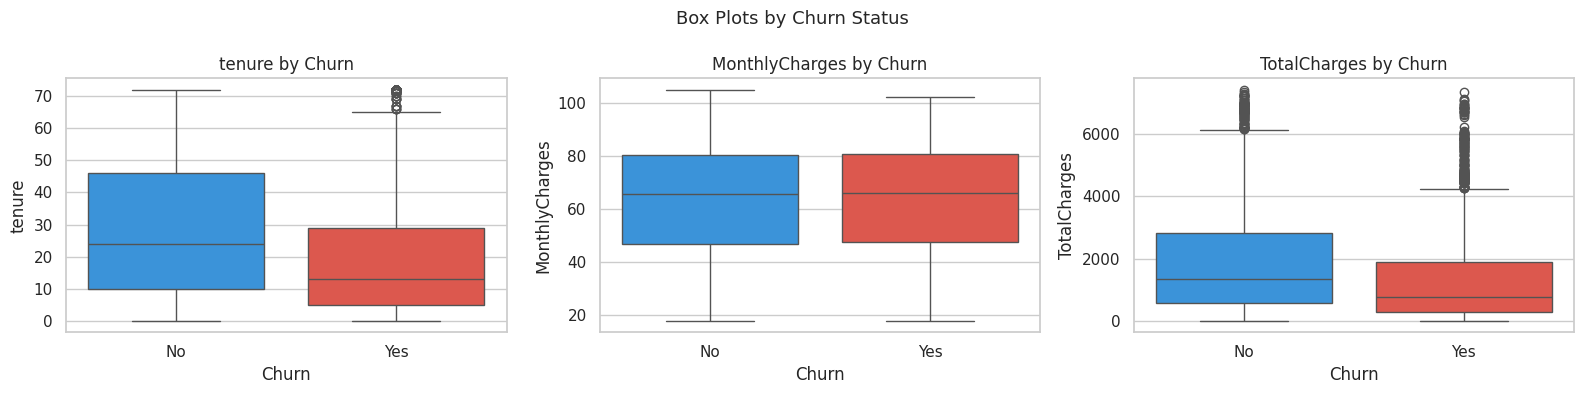

In [9]:
# Feature distributions and box plots

## 6. Bivariate Analysis — 6 Features vs Churn

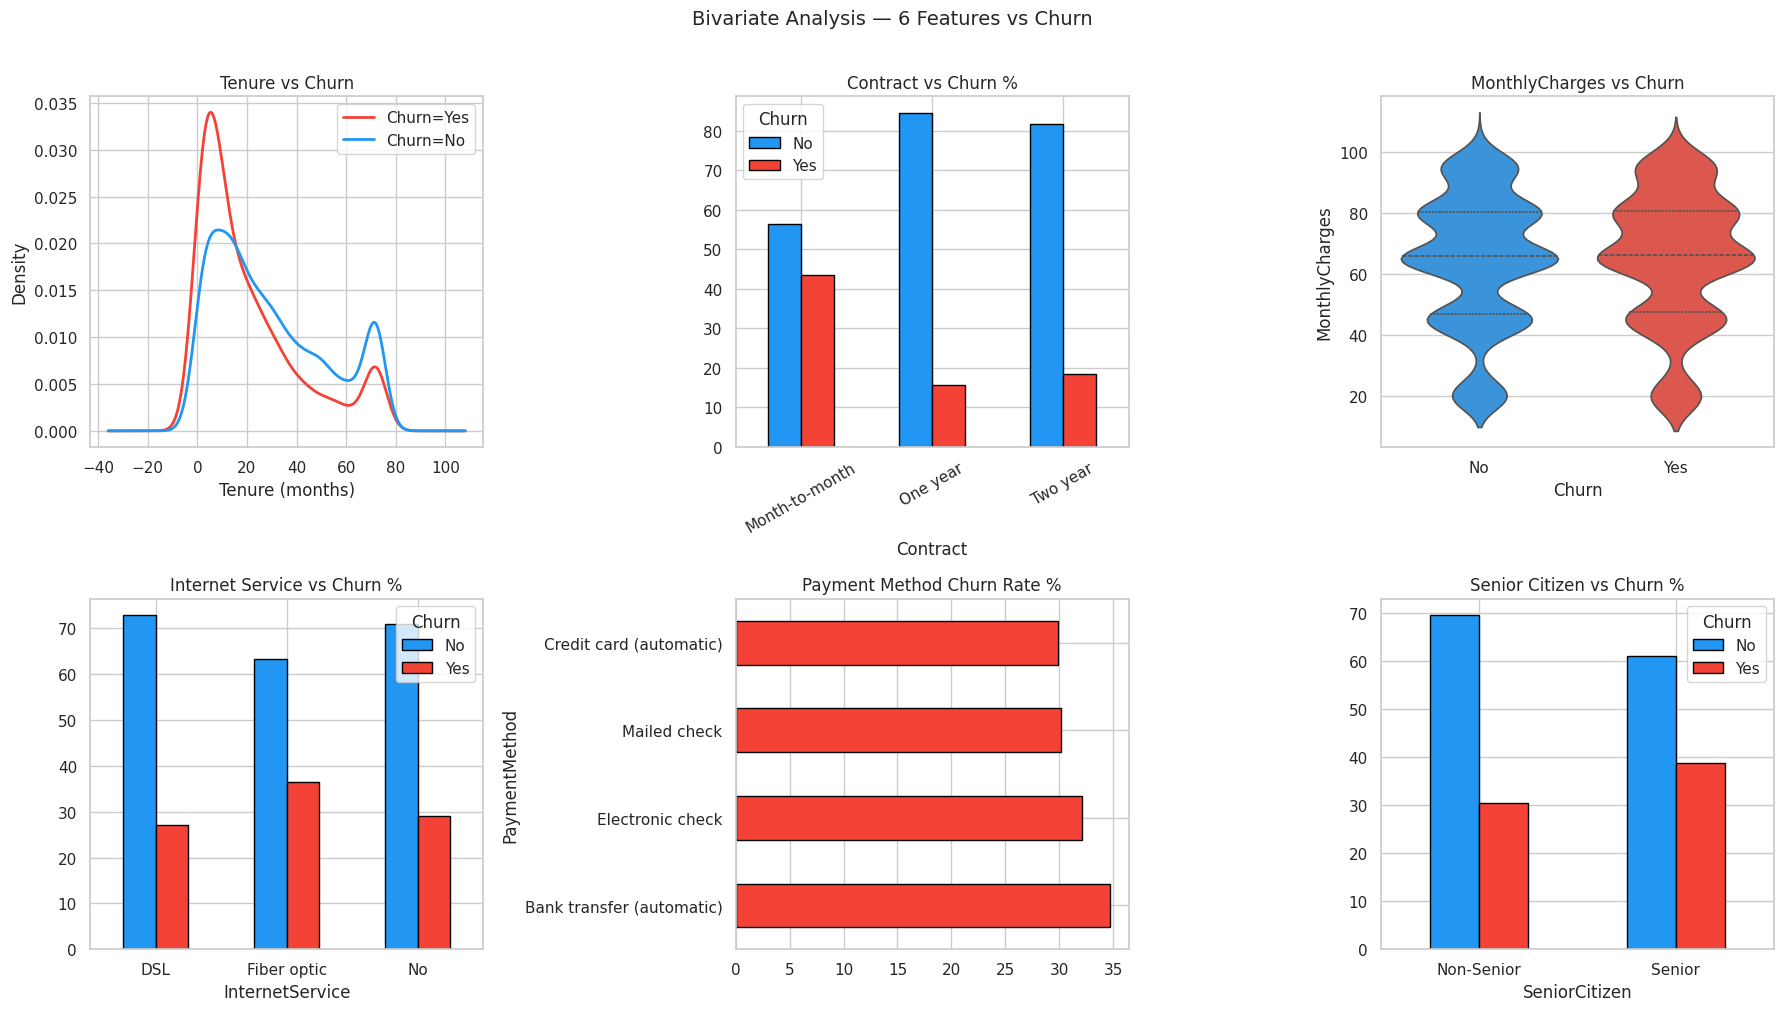

In [10]:
# Bivariate analysis

## 7. Business Insights

| # | Insight | Evidence | Recommendation |
|---|---------|----------|----------------|
| 1 | **Month-to-month customers churn most** | ~44% churn rate vs ~3% for 2-year | Offer 15-20% discount to upgrade to annual contracts |
| 2 | **Fiber optic = high churn** | ~37% churn despite premium pricing | Bundle OnlineSecurity/Backup to improve perceived value |
| 3 | **New customers are highest risk** | Tenure <12m has highest churn density | Launch first-year onboarding retention programme |
| 4 | **Electronic check users churn most** | ~32% churn rate | Migrate to auto-pay with $5/month incentive |
| 5 | **Senior citizens at elevated risk** | ~39% vs ~30% for non-seniors | Dedicated senior plan with simplified billing |

In [11]:
print('EDA Complete ✅')

✅ EDA Complete!

Key Findings:
  Churn rate       : 31.7%
  Month-to-month   : 43.6% churn
  Fiber optic      : 36.6% churn
  Elec. check      : 32.1% churn
  Senior citizens  : 38.8% churn
